## Code for plotting the simulations results for the main panel figure

### Bipartition correctness 

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def extract_chr_from_dirname(dirname):
    match = re.search(r'msa_(chr[\w\d]+)_sim_cases_\d+', dirname)
    return match.group(1) if match else None

def find_chr_dirs(base_path):
    chr_dirs = []
    for entry in os.listdir(base_path):
        full_path = os.path.join(base_path, entry)
        if os.path.isdir(full_path) and re.match(r'^msa_chr[\w\d]+_sim_cases_\d+$', entry):
            chr_dirs.append(full_path)
    return chr_dirs

def find_case_dirs(chr_dir):
    case_dirs = []
    for entry in os.listdir(chr_dir):
        full_path = os.path.join(chr_dir, entry)
        if os.path.isdir(full_path) and re.match(r'^case_\d+$', entry):
            case_dirs.append(full_path)
    return sorted(case_dirs, key=lambda x: int(re.search(r'case_(\d+)', x).group(1)))

def read_all_tree_comparisons(base_dir):
    all_dfs = []
    for chr_dir in find_chr_dirs(base_dir):
        chr_name = extract_chr_from_dirname(os.path.basename(chr_dir))
        if not chr_name:
            print(f"Warning: Could not extract chr from {chr_dir}")
            continue
        for case_dir in find_case_dirs(chr_dir):
            file_path = os.path.join(case_dir, 'tree_comparison.tsv')
            if os.path.isfile(file_path):
                df = pd.read_csv(file_path, sep='\t', header=None)
                df.columns = ['height', 'num_leaves', 'correct']
                df['case'] = os.path.basename(case_dir)
                df['chr'] = chr_name
                all_dfs.append(df)
            else:
                print(f"Warning: Missing file {file_path}")
    return all_dfs

def chr_sort_key(chr_name):
    match = re.match(r'chr(\d+)', chr_name)
    return int(match.group(1)) if match else float('inf')


In [2]:
base_dir = '/private/groups/patenlab/mira/centrolign/simulations/MSA_simulations/'

all_dfs = read_all_tree_comparisons(base_dir)
combined_df = pd.concat(all_dfs, ignore_index=True)
combined_df['correct_label'] = combined_df['correct'].map({0: 'Incorrect', 1: 'Correct'})

chromosomes = sorted(combined_df['chr'].unique(), key=chr_sort_key)
combined_df['chr'] = pd.Categorical(combined_df['chr'], categories=chromosomes, ordered=True)

print(f"{len(combined_df)} rows across {len(chromosomes)} chromosomes")
combined_df.head()


2691 rows across 17 chromosomes


,height,num_leaves,correct,case,chr,correct_label
0,19,2,1,case_1,chr16,Correct
1,22,3,1,case_1,chr16,Correct
2,37,2,1,case_1,chr16,Correct
3,50,3,1,case_1,chr16,Correct
4,26,2,1,case_1,chr16,Correct


/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 6.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 8.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

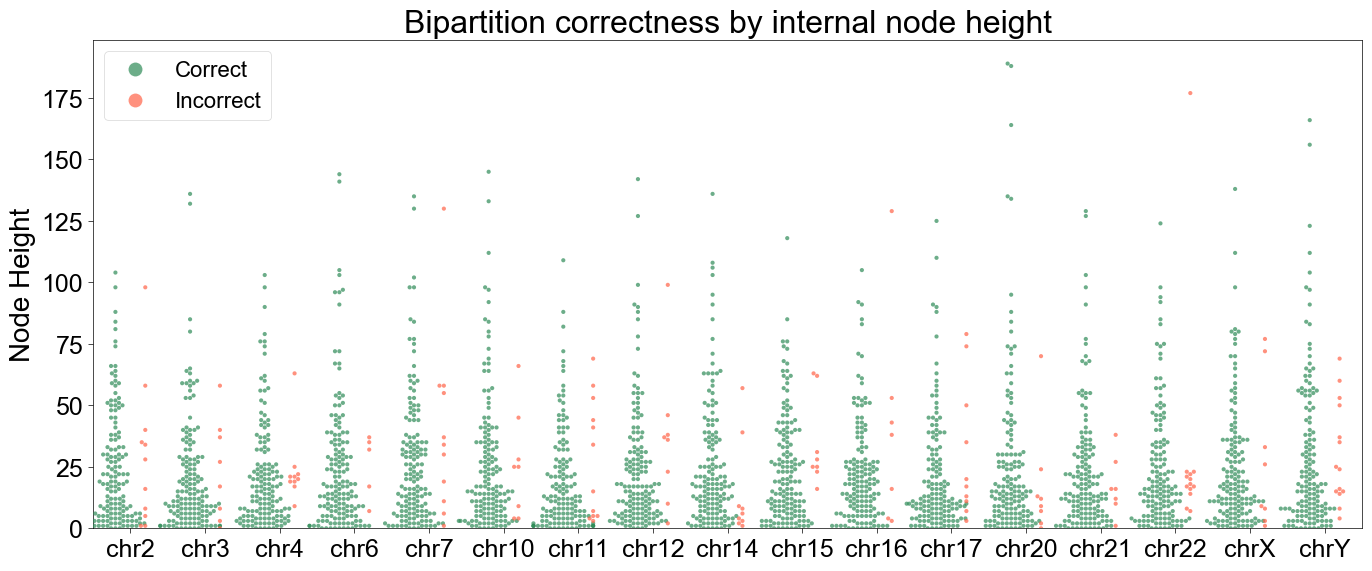

In [3]:
plt.rcParams.update({
    'font.size': 16,
    'font.family': 'Arial',
    'axes.linewidth': 0.5,
    'patch.linewidth': 0.5,
    'lines.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

plt.figure(figsize=(14, 6))
sns.swarmplot(
    data=combined_df, x='chr', y='height', hue='correct_label',
    palette={'Incorrect': 'tomato', 'Correct': 'seagreen'},
    dodge=True, size=3, alpha=0.7
)
plt.ylabel("Node Height", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(bottom=0)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

leg = ax.get_legend()
leg.set_title('')
leg.get_frame().set_linewidth(0.5)
plt.setp(leg.get_texts(), fontsize=16)
plt.xlabel("")
leg = ax.get_legend()
leg.set_title('')
leg.get_frame().set_linewidth(0.5)
plt.setp(leg.get_texts(), fontsize=16)
for handle in leg.legend_handles:
    handle.set_markersize(10)


plt.title("Bipartition correctness by internal node height",fontsize=23)
plt.tight_layout()
plt.savefig('/private/groups/patenlab/mira/node_height_swarm.main.svg', format='svg', bbox_inches='tight')
plt.show()



### Simulations violin plots 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import matplotlib.lines as mlines

file_path = '/private/groups/patenlab/mira/centrolign/simulations/pairwise_simulations/summary_tables/pair_all_chroms_sim_cases_20250421_aln_summary_tables.txt'

column_names = [
    "case", "aligner", "distance", "truth_matches", "truth_match_rate",
    "matches", "match_rate", "mismatches", "mismatch_rate",
    "recall", "precision", "chr"
]

df = pd.read_csv(file_path, delim_whitespace=True, names=column_names)
df['F1'] = 2 * (df['precision'] * df['recall']) / (df['precision'] + df['recall'])
df['F1'] = df['F1'].fillna(0)
df = df[df['F1'] > 0]

def chr_sort_key(chr_name):
    match = re.match(r'chr(\d+)', chr_name)
    return int(match.group(1)) if match else float('inf')

chromosomes = sorted(df['chr'].unique(), key=chr_sort_key)
aligners = sorted(df['aligner'].unique())
group_means = df.groupby(['chr', 'aligner'])['F1'].mean().reset_index()

print(f"{len(df)} rows, {len(chromosomes)} chromosomes, aligners: {aligners}")


3051 rows, 17 chromosomes, aligners: ['centrolign', 'rama', 'unialigner']


/data/tmp/ipykernel_1177140/2582158431.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, names=column_names)


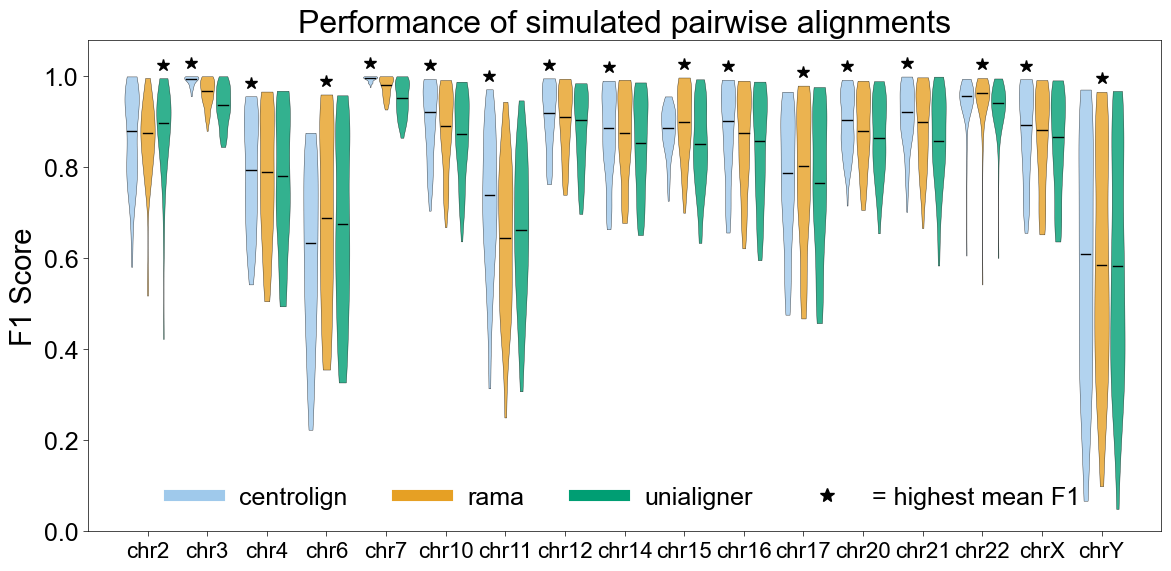

In [5]:
plt.rcParams.update({
    'font.size': 16,
    'font.family': 'Arial',
    'axes.linewidth': 0.5,
    'patch.linewidth': 0.5,
    'lines.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})


aligner_colors = {
    'centrolign': '#9FC9EB',
    'rama':       '#E6A024',
    'unialigner': '#009E73',
    'MSA':        '#CC79A7',
    'pairwise':   '#0072B2',
}

group_width = 0.8
box_width = group_width / len(aligners)
x_group_positions = np.arange(len(chromosomes))
aligner_offsets = np.linspace(
    -group_width / 2 + box_width / 2,
    group_width / 2 - box_width / 2,
    len(aligners)
)

fig, ax = plt.subplots(figsize=(12, 6))

plt.rcParams.update({
    'font.family': 'Arial',
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})


violin_centers = {}

for i, chr_ in enumerate(chromosomes):
    chr_data = df[df['chr'] == chr_]
    positions = x_group_positions[i] + aligner_offsets

    for j, aln in enumerate(aligners):
        y_vals = chr_data[chr_data['aligner'] == aln]['F1'].values
        if len(y_vals) == 0:
            continue

        parts = ax.violinplot(
            dataset=y_vals,
            positions=[positions[j]],
            widths=box_width * 0.9,
            showmeans=False,
            showmedians=True,
            showextrema=False
        )
        for pc in parts['bodies']:
            pc.set_facecolor(aligner_colors.get(aln, 'gray'))
            pc.set_alpha(0.8)
            pc.set_edgecolor('black')
            pc.set_linewidth(0.3)


        median_val = np.median(y_vals)
        ax.plot(
            [positions[j] - box_width * 0.3, positions[j] + box_width * 0.3],
            [median_val, median_val],
            color='black', linewidth=1
        )
        violin_centers[(chr_, aln)] = positions[j]

# Stars for highest mean F1 per chromosome
for chr_ in chromosomes:
    means_chr = group_means[group_means['chr'] == chr_]
    if means_chr.empty:
        continue
    best_row = means_chr.loc[means_chr['F1'].idxmax()]
    best_aligner = best_row['aligner']
    if (chr_, best_aligner) not in violin_centers:
        continue
    x_star = violin_centers[(chr_, best_aligner)]
    max_f1 = df[(df['chr'] == chr_) & (df['aligner'] == best_aligner)]['F1'].max()
    ax.plot(x_star, max_f1 + 0.03, marker='*', color='black',
            markersize=9, zorder=5, linestyle='None')


ax.set_xticks(x_group_positions)
ax.set_xticklabels(chromosomes, fontsize=16)
ax.set_xlim(-1, len(chromosomes))
ax.set_ylabel('F1 Score', fontsize=21)
ax.set_title('Performance of simulated pairwise alignments', fontsize=23)
ax.tick_params(axis='y', labelsize=18)

legend_handles = [
    plt.Line2D([0], [0], color=aligner_colors.get(aln, 'gray'), lw=8, label=aln)
    for aln in aligners
]
legend_handles.append(
    mlines.Line2D([], [], color='black', marker='*', linestyle='None', markersize=10, label='= highest mean F1')
)
ax.legend(handles=legend_handles, loc='lower center', ncol=len(aligners) + 1, frameon=False, fontsize=18)

plt.tight_layout()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

#plt.savefig('/private/groups/patenlab/mira/centrolign/github/centrolign_analysis/analysis_notes/simulations/figures/msa_vs_pairwise_simulations_violins.png', dpi=600, bbox_inches='tight')
plt.savefig('/private/groups/patenlab/mira/centrolign/pairwise_simulations_violins.main.svg', bbox_inches='tight')
plt.show()


/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 8.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 8.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

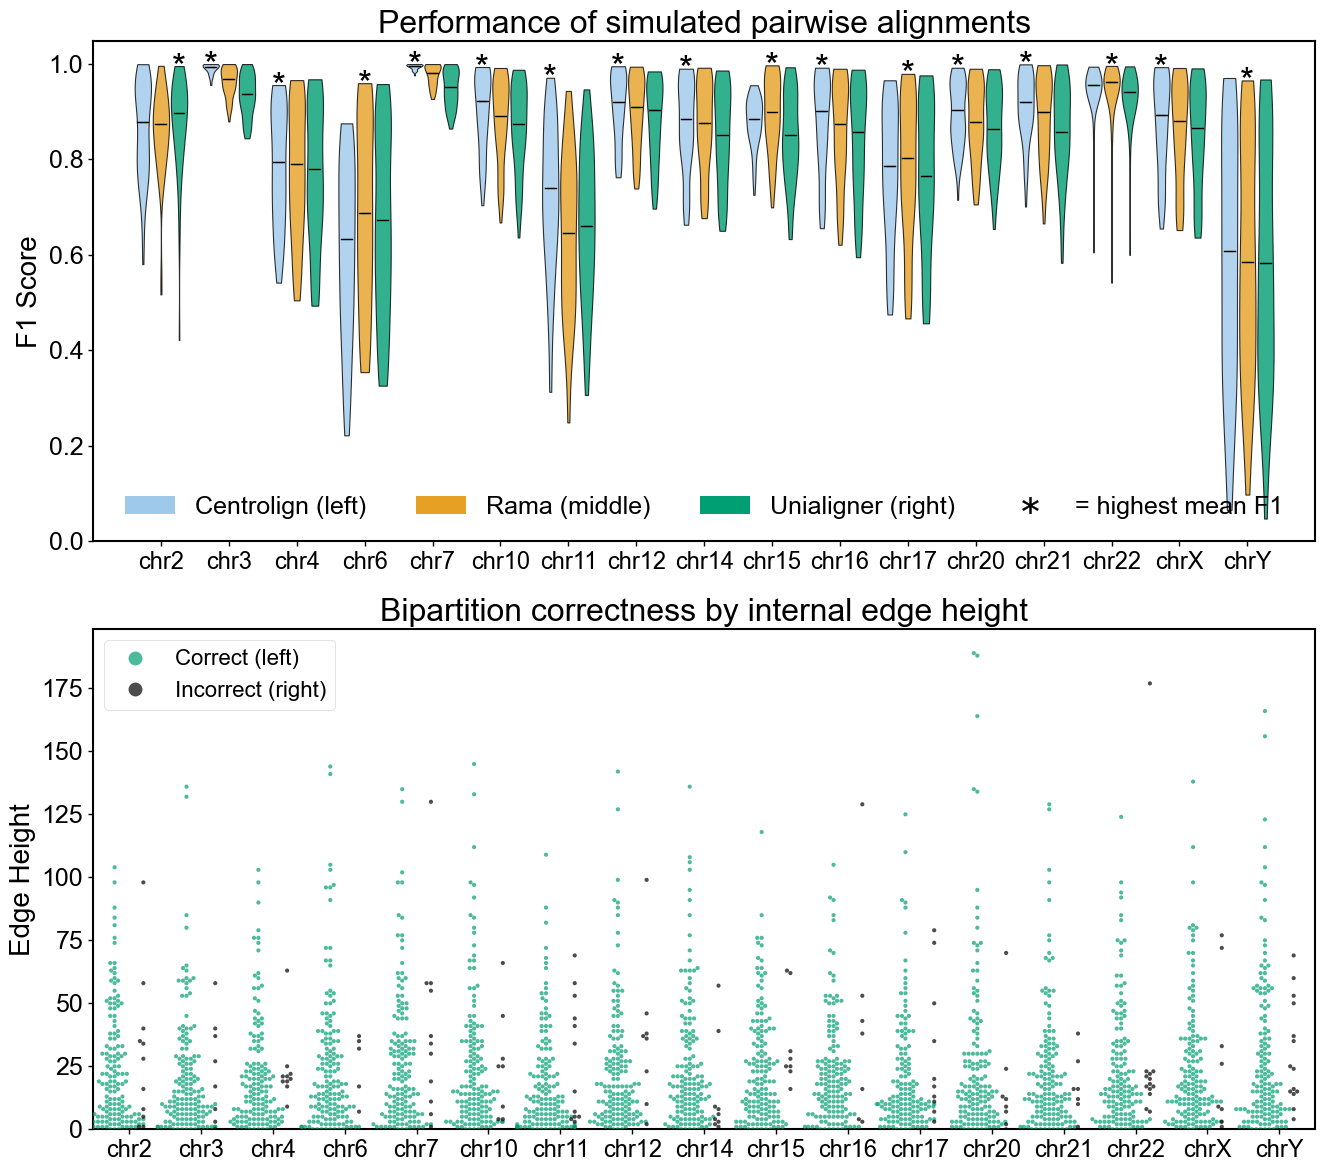

In [14]:
plt.rcParams.update({
    'font.size': 16,
    'font.family': 'Arial',
    'axes.linewidth': 1,
    'patch.linewidth': 1,
    'lines.linewidth': 1,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
})

fig, (ax2, ax1) = plt.subplots(2, 1, figsize=(14, 12))


# ── Panel 1: node height swarm ────────────────────────────────────────────────
sns.swarmplot(
    data=combined_df, x='chr', y='height', hue='correct_label',
    palette={'Incorrect': 'black', 'Correct': '#009E73'},
    dodge=True, size=3, alpha=0.7, ax=ax1
)
handles, labels = ax1.get_legend_handles_labels()
label_map = {'Correct': 'Correct (left)', 'Incorrect': 'Incorrect (right)'}
labels = [label_map.get(l, l) for l in labels]
ax1.legend(handles, labels, title='', fontsize=16,
           frameon=True)
leg1 = ax1.get_legend()
leg1.get_frame().set_linewidth(0.5)
for handle in leg1.legend_handles:
    handle.set_markersize(10)

ax1.set_ylabel("Edge Height", fontsize=20)
ax1.set_xlabel("")
ax1.tick_params(axis='x', labelsize=18)
ax1.tick_params(axis='y', labelsize=18)
ax1.set_xticklabels(chromosomes, fontsize=17)
ax1.set_ylim(bottom=0)
ax1.set_title("Bipartition correctness by internal edge height", fontsize=23)
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)

leg1 = ax1.get_legend()
leg1.set_title('')
leg1.get_frame().set_linewidth(0.5)
plt.setp(leg1.get_texts(), fontsize=16)
for handle in leg1.legend_handles:
    handle.set_markersize(10)

# ── Panel 2: F1 violin ────────────────────────────────────────────────────────
violin_centers = {}

for i, chr_ in enumerate(chromosomes):
    chr_data = df[df['chr'] == chr_]
    positions = x_group_positions[i] + aligner_offsets

    for j, aln in enumerate(aligners):
        y_vals = chr_data[chr_data['aligner'] == aln]['F1'].values
        if len(y_vals) == 0:
            continue

        parts = ax2.violinplot(
            dataset=y_vals,
            positions=[positions[j]],
            widths=box_width * 0.9,
            showmeans=False,
            showmedians=True,
            showextrema=False
        )
        for pc in parts['bodies']:
            pc.set_facecolor(aligner_colors.get(aln, 'gray'))
            pc.set_alpha(0.8)
            pc.set_edgecolor('black')
            pc.set_linewidth(0.8)

        median_val = np.median(y_vals)
        ax2.plot(
            [positions[j] - box_width * 0.3, positions[j] + box_width * 0.3],
            [median_val, median_val],
            color='black', linewidth=1
        )
        violin_centers[(chr_, aln)] = positions[j]

for chr_ in chromosomes:
    means_chr = group_means[group_means['chr'] == chr_]
    if means_chr.empty:
        continue
    best_row = means_chr.loc[means_chr['F1'].idxmax()]
    best_aligner = best_row['aligner']
    if (chr_, best_aligner) not in violin_centers:
        continue
    x_star = violin_centers[(chr_, best_aligner)]
    max_f1 = df[(df['chr'] == chr_) & (df['aligner'] == best_aligner)]['F1'].max()
    ax2.annotate('*', xy=(x_star, max_f1+.03),
                 fontsize=26, ha='center', va='top',
                 fontfamily='Arial', color='black',
                 fontweight='light')


ax2.set_xticks(x_group_positions)
ax2.set_xticklabels(chromosomes, fontsize=17)
ax2.set_xlim(-1, len(chromosomes))
ax2.set_ylabel('F1 Score', fontsize=20)
ax2.set_xlabel('')
ax2.set_title('Performance of simulated pairwise alignments', fontsize=23)
ax2.tick_params(axis='y', labelsize=18)
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)

from matplotlib.patches import Patch

label_map = {
    'centrolign': 'Centrolign (left)',
    'rama':       'Rama (middle)',
    'unialigner': 'Unialigner (right)',
}

legend_handles = [
    Patch(facecolor=aligner_colors.get(aln, 'gray'), edgecolor='none',
          label=label_map.get(aln, aln))
    for aln in aligners
]

legend_handles.append(
    mlines.Line2D([], [], color='black', marker='$*$', markeredgecolor='black',
                  markeredgewidth=0.3, markersize=12, linestyle='None',
                  label='= highest mean F1')
)


ax2.legend(handles=legend_handles, loc='lower center', ncol=len(aligners) + 1, frameon=False, fontsize=18)

plt.tight_layout()
plt.savefig('/private/groups/patenlab/mira/centrolign/simulations_combined_panel.svg', format='svg', bbox_inches='tight')
plt.savefig('/private/groups/patenlab/mira/centrolign/simulations_combined_panel.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
pct_correct = combined_df['correct'].mean() * 100
print(f"Percent correct bipartitions (overall): {pct_correct:.1f}%")

per_chr = combined_df.groupby('chr')['correct'].mean() * 100
print("\nPercent correct bipartitions per chromosome:")
for chr_, pct in per_chr.items():
    print(f"  {chr_}: {pct:.1f}%")


Percent correct bipartitions (overall): 94.2%

Percent correct bipartitions per chromosome:
  chr2: 93.0%
  chr3: 95.0%
  chr4: 93.5%
  chr6: 96.9%
  chr7: 93.2%
  chr10: 94.9%
  chr11: 92.3%
  chr12: 95.0%
  chr14: 94.3%
  chr15: 95.0%
  chr16: 95.5%
  chr17: 93.6%
  chr20: 94.9%
  chr21: 95.6%
  chr22: 91.8%
  chrX: 95.0%
  chrY: 91.4%


/data/tmp/ipykernel_1177140/1228666378.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_chr = combined_df.groupby('chr')['correct'].mean() * 100
